<a href="https://colab.research.google.com/github/emrizky1/machine-learning/blob/main/JS05/JS05_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

X = np.absolute(X)
X = np.round(X, 2) * 100
X = X.astype(int)

print(X)
print(y)

[[ 11 102]
 [ 95 167]
 [104  81]
 [165 272]
 [ 66  39]
 [ 37 114]
 [179 344]
 [129 125]
 [ 64  60]
 [ 93 100]
 [229   4]
 [252 165]
 [ 84 260]
 [ 25 195]
 [ 67  87]
 [  9 147]
 [ 91 194]
 [ 39 275]
 [287 179]
 [ 20 130]
 [111 221]
 [ 46 108]
 [204 139]
 [ 89 133]
 [ 33  10]
 [ 67 124]
 [ 51  44]
 [138 136]
 [182 231]
 [  1  42]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [2]:
import pandas as pd

y_new = y.reshape(len(y), 1)
data = np.concatenate((X, y_new), axis=1)
nama_kolom = ['Feature 1', 'Feature 2', 'Label']
df = pd.DataFrame(data, columns=nama_kolom)
df.head()

,Feature 1,Feature 2,Label
0,11,102,0
1,95,167,0
2,104,81,0
3,165,272,0
4,66,39,0


In [3]:
labels = {
    1 : 'Class A',
    0 : 'Class B'
}

df_label = df.copy()
df_label['Label'] = df_label['Label'].map(labels)
df_label.head()

,Feature 1,Feature 2,Label
0,11,102,Class B
1,95,167,Class B
2,104,81,Class B
3,165,272,Class B
4,66,39,Class B


/tmp/ipykernel_1955/2552175783.py:9: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Class A')
/tmp/ipykernel_1955/2552175783.py:10: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Class B')


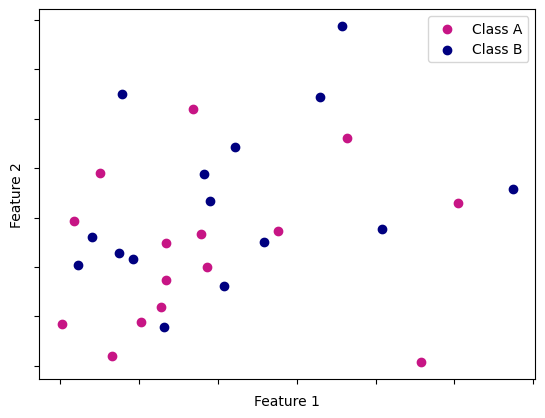

In [4]:
import matplotlib.pyplot as plt

colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

gb = df_label.groupby(['Label'])
class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['class_a'])
plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['class_b'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class A', 'Class B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mnb = MultinomialNB()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mnb.fit(X_train, y_train)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)
mnb.fit(X_train, y_train)
y_train_pred = mnb.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)
y_test_pred = mnb.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

print(f'Training Accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')

Training Accuracy: 0.6190476190476191
Test accuracy: 0.1111111111111111


In [6]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_train_pred_gnb = gnb.predict(X_train)
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)
y_test_pred_gnb = gnb.predict(X_test)
acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f'Training Accuracy: {acc_train_gnb}')
print(f'Test accuracy: {acc_test_gnb}')

Training Accuracy: 0.6666666666666666
Test accuracy: 0.3333333333333333
